## 1. Data Loading and Exploration

### 1.1 Modules and Libraries

In [ ]:
import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/data_model_davies'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.2 Numerical Parameters

In [ ]:
# Numerical parameters
nlat = 78
nlon = 71
nz = 500 # Initial number of rioters

Lr = 6 # most recent time steps in our discretised temporal scheme
Lp = 12 # response lag of the police units

Nt = 500 # Rate at which individuals choose to participate at time t
Ntt = 10

dt = 0.1 # delta time
sim_time = 0.0 # init time

### 1.3 Simulation Parameters

In [ ]:
# Simulation parameters

# alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)
# beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
#         target affects the attractiveness of that target)
# gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
#          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)

alpha_r = 0.5
beta_r = 0.5
gamma_r = 0.11

mu = 1.0 # This is an exponent in the function for the probability of rioting in an area, related to how deprivation affects the likelihood of rioting

# alpha_p: Attractiveness of a location to police. It influences how police resources are allocated based on the characteristics of the location.
# gamma_p: Impact of the number of rioters on the police requirement at a site.

alpha_p = 1.0
gamma_p = 0.01

eta = 0.005 # Infection rate. It determines how quickly individuals are influenced by the ongoing disorder and become active rioters
tau = 0.75 # Arrest rate parameter. It determines how quickly rioters are arrested by police when they are present
Ptotal = 500.0  # Total number of police forces

### 1.4 Data Sources

In [ ]:
# Data sources

# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# i: Residential Área
# j: Retail Center (Potential Riot Site)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")  # Ponderated distances (the distance between the centroids of i and j)
Dj_cl= np.loadtxt(f"{FOLDER_PATH}/data_sosafe.dat") # Data from SOSAFE (real data)

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Ai = np.zeros((nlat, nlon), "d")  # Active population
Ci = np.zeros((nlat, nlon), "d")  # Capture rate
rho = np.ones((nlat, nlon), "d")  # Deprivation distribution (is a measure of the deprivation in i)

Rj = np.zeros(nz, "d")  # Rioters (Ri: the number of rioters whose residece in in a given zone i)
# Rj = np.loadtxt('Rj_init.dat') # Initial 100 rioters distribution
Pj = np.zeros(nz, "d")  # Police officers
We_ij = np.zeros((nlat, nlon, nz), "d")  # Benefit computation (We_ij: effective attractiveness)
fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation
Sij = np.zeros((nlat, nlon, nz), "d")  # Population flow between i and j (An estimate of the number of rioters from i who are participating in disorder in j at time t)
Dj = np.zeros(nz, "d")  # The number of rioters in j
Ddel = np.zeros((nz, Lp), "d")  # Police requirement, time-delayed
Dej = np.zeros(nz, "d")

## 2. EDA and Plots

### 2.1 Origin Density 500m, 5am - 10am

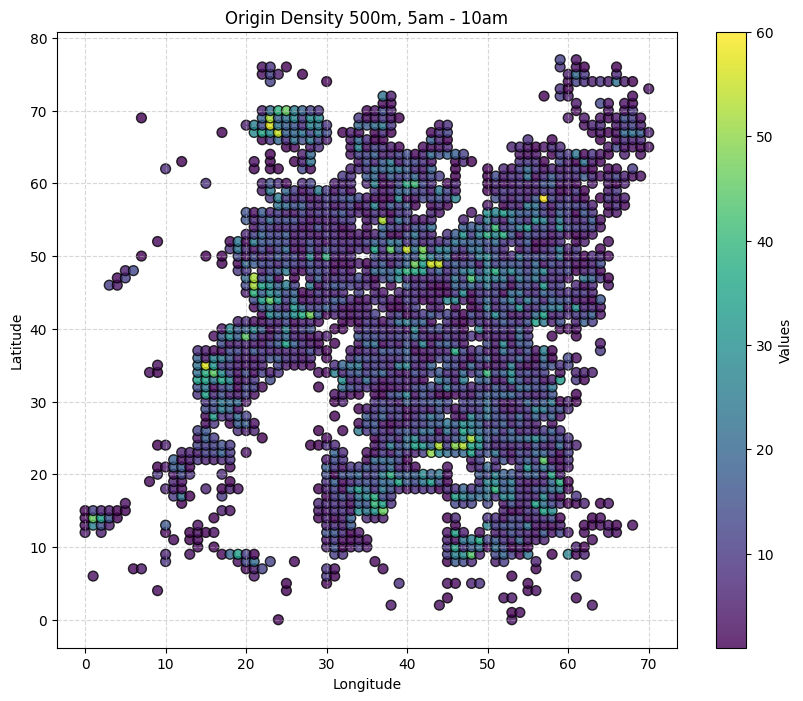

In [ ]:
# Figure Size
plt.figure(figsize=(10, 8))

# Get pos from not null values
x, y = np.where(origin != 0)

# Data viz
plt.scatter (y, x, c=origin[x, y], cmap='viridis', s=50, edgecolor='k', alpha=0.8)
plt.colorbar(label='Values')  # Barra de color para ver los valores
plt.title('Origin Density 500m, 5am - 10am')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 2.2 Destination Density 500m, 5am - 10am

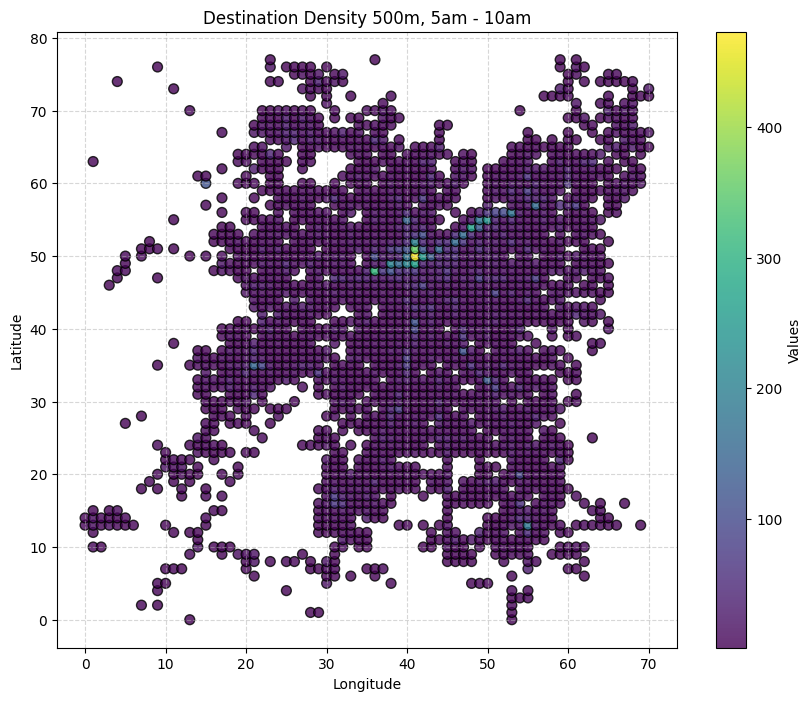

In [ ]:
# Figure Size
plt.figure(figsize=(10, 8))

# Get pos from not null values
x, y = np.where(destination != 0)

# Data viz
plt.scatter(y, x, c=destination[x, y], cmap='viridis', s=50, edgecolor='k', alpha=0.8)
plt.colorbar(label='Values')  # Color Bar
plt.title('Destination Density 500m, 5am - 10am')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 2.3 Rioter's Targets (Zj)

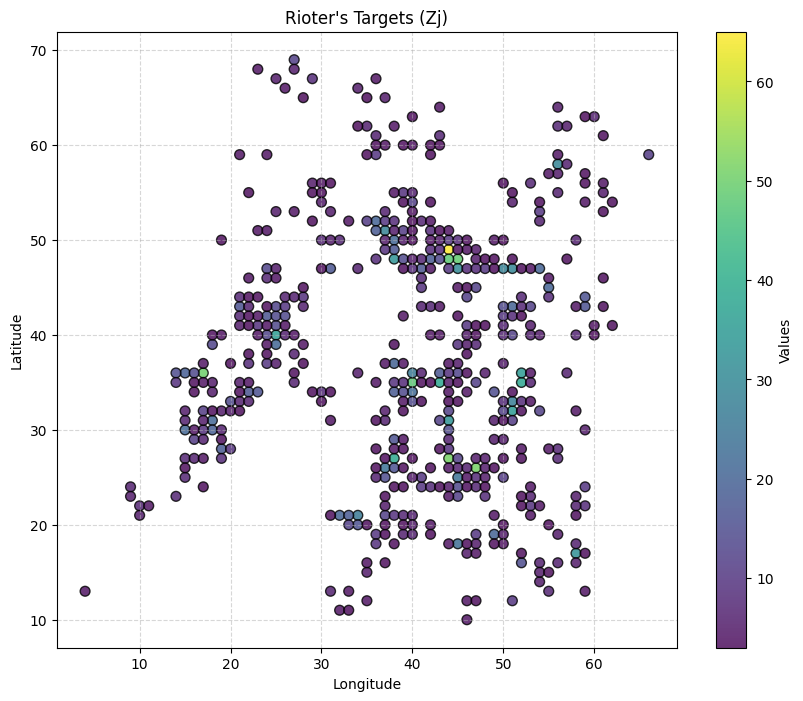

In [ ]:
# Get positions lat, lon
lat, lon, values = Zj[:, 0], Zj[:, 1], Zj[:, 2]

# Figure Size
plt.figure(figsize=(10, 8))

# Data viz
plt.scatter(lon, lat, c=values, cmap='viridis', s=50, edgecolor='k', alpha=0.8)
plt.colorbar(label='Values')  # Color Bar
plt.title("Rioter's Targets (Zj)")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 2.4 Rioter's Targets : SOSAFE (Dj_cl)

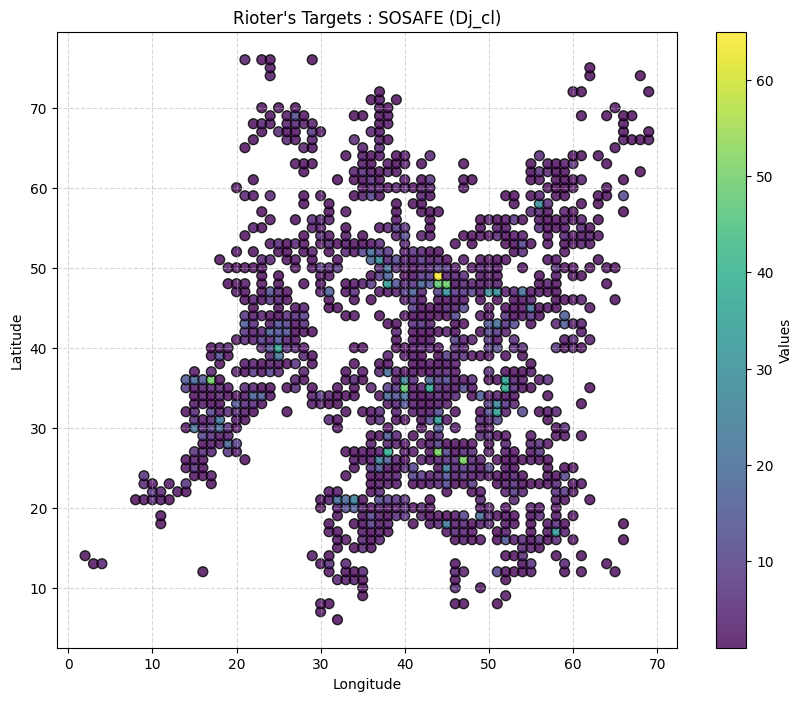

In [ ]:
# Crear una figura
plt.figure(figsize=(10, 8))

# Obtener las posiciones de los puntos (valores no ceros)
x, y = np.where(Dj_cl != 0)

# Visualizar los puntos
plt.scatter(y, x, c=Dj_cl[x, y], cmap='viridis', s=50, edgecolor='k', alpha=0.8)
plt.colorbar(label='Values')  # Barra de color para ver los valores
plt.title("Rioter's Targets : SOSAFE (Dj_cl)")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar el gráfico
plt.show()


### 2.5 HeatMap - Rioter's Targets : SOSAFE (Dj_cl)

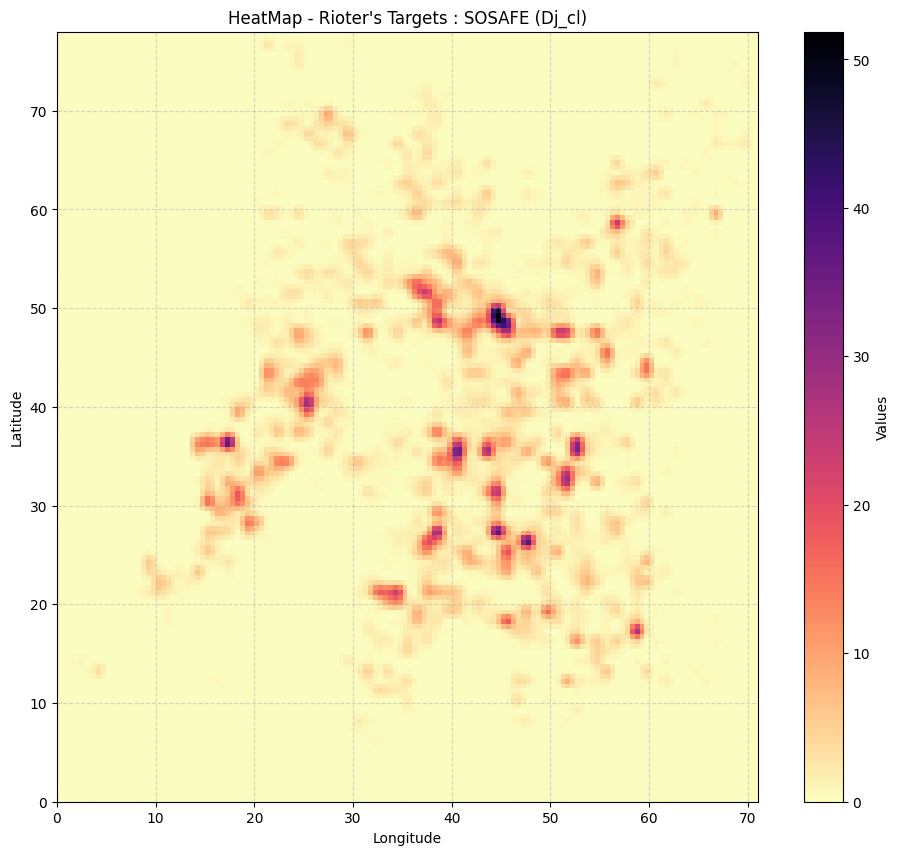

In [ ]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

def plot_heatmap():

    # Asumiendo que Dj_cl es tu matriz de datos original
    rows, cols = Dj_cl.shape

    # Crear coordenadas para los datos originales
    x = np.arange(cols)
    y = np.arange(rows)

    # Crear una función de interpolación
    f = RegularGridInterpolator((y, x), Dj_cl)

    # Crear una malla más fina
    x_new = np.linspace(0, cols-1, cols*2)
    y_new = np.linspace(0, rows-1, rows*2)
    xx, yy = np.meshgrid(x_new, y_new)

    # Interpolar
    pts = np.array([yy.flatten(), xx.flatten()]).T
    z = f(pts).reshape(xx.shape)

    # Aplicar suavizado gaussiano
    sigma = 0.05  # Ajusta este valor para controlar el grado de suavizado
    z_smooth = gaussian_filter(z, sigma=sigma)

    # Plotear
    plt.figure(figsize=(12, 10))
    plt.imshow(z_smooth, cmap='magma_r', extent=[0, cols, 0, rows], origin='lower')
    plt.colorbar(label='Values')  # Barra de color para ver los valores
    plt.title("HeatMap - Rioter's Targets : SOSAFE (Dj_cl)")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.5)

plot_heatmap()

## 3. Simulation

### 3.1 Parameters Before Simulation

In [ ]:
# # Computation loop
# counter = 0
# idxr = 0
# counterp = 0
# idxp = 0

# # Testing params
# Nt, Ntt = 500, 10
# # Nt = 500 # Rate at which individuals choose to participate at time t
# # Ntt = 10

# # Data sources
# Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
# dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")

# # Precalculated arrays
# Rj = np.zeros(nz, "d")
# Ai = np.zeros((nlat, nlon), "d")  # Active population
# Pj = np.zeros(nz, "d")  # Police officers
# Ci = np.zeros((nlat, nlon), "d")  # Capture rate
# fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation

# auxij1 = np.exp(-beta_r * dij)
# dij = 1.0 * Zj[:, 2] * auxij1 / np.max(Zj[:, 2])


# # alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)
# # beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
# #         target affects the attractiveness of that target)
# # gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
# #          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)

# alpha_r = 0.5
# beta_r = 0.5
# gamma_r = 0.11

# print(f"Before Sim Rj: {Rj.shape}")
# print(np.min(Rj), np.max(Rj),"\n")
# print(f"Before Sim Ai: {Ai.shape}")
# print(np.min(Ai), np.max(Ai),"\n")
# print(f"Before Sim Ii: {Ii.shape}")
# print(np.min(Ii), np.max(Ii),"\n")
# print(f"Before Sim dij: {dij.shape}")
# print(np.min(dij), np.max(dij),"\n")

### 3.2 Original Simulation

In [ ]:
# # Computation loop
# counter = 0
# idxr = 0
# counterp = 0
# idxp = 0

# # Testing params
# Nt, Ntt = 10, 10
# Rj = np.zeros(nz, "d")

# # Precalculated arrays

# auxij1 = np.exp(-beta_r * dij)
# dij = 1.0 * Zj[:, 2] * auxij1 / np.max(Zj[:, 2])

# print("Starting loop ...")
# timer0 = time.time()
# t = 0

# for nn in range(Nt):
#     for mm in range(Ntt):

#         fj = np.exp(-np.floor(gamma_r * Pj / (Rj + 1.0e-20))) # 500 Values
#         Wij = fj * dij # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
#         Wi = np.sum(Wij, axis=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i

#         P_off = rho * Wi / (1.0 + Wi) # P_off shape: 78, 71

#         # fjdel storage
#         idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
#         fjdel[:, idxr] = fj # fjdel: 500, 6

#         if counter >= Lr:
#             dnm = Lr
#         else:
#             dnm = counter + 1
#         # Delayed term computation
#         # print (f"Lr: {Lr}, idxr: {idxr}, dnm: {dnm}, counter: {counter}")
#         We_ij = np.sum(fjdel, axis=1) * dij / dnm

#         # Flow computation step 1i
#         auxw = Ai / (np.sum(We_ij, axis=2) + 1.0e-20)

#         # Flow computation step 2, this loop must be vectorized
#         # for jj in range(nz):
#         #     Sij[:, :, jj] = auxw[:, :] * We_ij[:, :, jj]

#         Sij = auxw[:, :, np.newaxis] * We_ij

#         # Rioter computation

#         Rj = np.sum(np.sum(Sij, axis=1), axis=0)

#         # Police Interaction
#         Dj[:] = Zj[:, 2] ** (alpha_p) * np.exp(gamma_p * Rj[:])

#         # Delayed term computation
#         idxp = counter - (Lp) * int(counter / Lp)
#         Ddel[:, idxp] = Dj[:]
#         if counter >= Lp:
#             dnm = Lp
#         else:
#             dnm = counter + 1

#         Dej = np.sum(Ddel, axis=1) / dnm
#         Pj = Ptotal * Dej / np.sum(Dej)
#         counter += 1

#         # Capture rate
#         fj = 1.0 - np.exp(-np.floor(Pj / (Rj + 1.0e-20)))
#         Ci = tau * np.sum(Sij * fj, axis=2)

#         # Time step for Ai and Ii
#         Ai += dt * (eta * P_off * Ii - Ci)
#         Ii += -dt * eta * P_off * Ii
#         t += dt

# timer1 = time.time()
# print("Total execution time: ", timer1 - timer0)

### 3.3 Optimazed Simulation with CuPy

In [ ]:
# import cupy as cp

# # Convertir todos los parámetros de tipo Numpy Array a CuPy Arrray antes del bucle
# dij = cp.asarray(dij)
# Zj = cp.asarray(Zj)
# Rj = cp.asarray(Rj)
# Pj = cp.asarray(Pj)
# fjdel = cp.asarray(fjdel)
# Ai = cp.asarray(Ai)
# Ddel = cp.asarray(Ddel)
# Ii = cp.asarray(Ii)
# rho = cp.asarray(rho)
# Dj = cp.asarray(Dj)

# # Convertir escalares o parámetros adicionales a CuPy
# beta_r = cp.float32(beta_r)  # Asegúrate de que sea un escalar de CuPy
# gamma_r = cp.float32(gamma_r)
# alpha_p = cp.float32(alpha_p)
# gamma_p = cp.float32(gamma_p)
# Ptotal = cp.float32(Ptotal)
# dt = cp.float32(dt)
# tau = cp.float32(tau)
# eta = cp.float32(eta)  # Asegúrate de definir eta antes

# print("Starting loop ...")
# timer0 = time.time()
# sim_time = cp.float32(0)

# print(f"nz value: {nz}")
# print(f"counter value: {counter}")

# for nn in range(Nt):
#     for mm in range(Ntt):
#         fj = cp.exp(-cp.floor(gamma_r * Pj / (Rj + 1.0e-20)))

#         Wij = fj * dij

#         Wi = cp.sum(Wij, axis=2)

#         P_off = rho * Wi / (1.0 + Wi)

#         idxr = counter - (Lr) * int(counter / Lr)

#         fjdel[:, idxr] = fj

#         if counter >= Lr:
#             dnm = Lr
#         else:
#             dnm = counter + 1

#         We_ij = cp.sum(fjdel, axis=1) * dij / dnm

#         auxw = Ai / (cp.sum(We_ij, axis=2) + 1.0e-20)

#         Sij = auxw[:, :, cp.newaxis] * We_ij

#         Rj = cp.sum(cp.sum(Sij, axis=1), axis=0)

#         Dj[:] = Zj[:, 2] ** (alpha_p) * cp.exp(gamma_p * Rj[:])

#         idxp = counter - (Lp) * int(counter / Lp)

#         Ddel[:, idxp] = Dj[:]

#         if counter >= Lp:
#             dnm = Lp
#         else:
#             dnm = counter + 1

#         Dej = cp.sum(Ddel, axis=1) / dnm

#         Pj = Ptotal * Dej / cp.sum(Dej)

#         counter += 1

#         fj = 1.0 - cp.exp(-cp.floor(Pj / (Rj + 1.0e-20)))

#         Ci = tau * cp.sum(Sij * fj, axis=2)

#         Ai += dt * (eta * P_off * Ii - Ci)

#         Ii += -dt * eta * P_off * Ii

#         sim_time += dt

# timer1 = time.time()
# print("Total execution time: ", timer1 - timer0)

In [ ]:
# print(f"After Sim Rj: {Rj.shape}")
# print(np.min(Rj), np.max(Rj),"\n")
# print(f"After Sim Ai: {Ai.shape}")
# print(np.min(Ai), np.max(Ai),"\n")
# print(f"After Sim Ii: {Ii.shape}")
# print(np.min(Ii), np.max(Ii),"\n")
# print(f"After Sim dij: {dij.shape}")
# print(np.min(dij), np.max(dij),"\n")

### 3.4 Optimization - Simulation Function (CuPy Opt)

#### 3.4.1 Simulation Function (CuPy Opt)

In [ ]:
from scipy.signal import find_peaks

# Simulation Function
def run_simulation(dij_sim, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p):
    from sklearn.preprocessing import MinMaxScaler

    Zj = cp.asarray(Zj)
    Ii = cp.asarray(Ii)
    dij_ = cp.asarray(dij_sim)

    Lr = cp.int32(6) # most recent time steps in our discretised temporal scheme
    Lp = cp.int32(12) # response lag of the police units

    beta_r = cp.float32(beta_r)
    gamma_r = cp.float32(gamma_r)
    alpha_p = cp.float32(alpha_p)
    gamma_p = cp.float32(gamma_p)

    eta = cp.float32(0.005) # Infection rate. It determines how quickly individuals are influenced by the ongoing disorder and become active rioters
    tau = cp.float32(0.75) # Arrest rate parameter. It determines how quickly rioters are arrested by police when they are present
    Ptotal = cp.int32(500)

    Nt, Ntt, nz, nlat, nlon = 500, 10, 500, 78, 71

    # Precalculated arrays
    Rj = cp.asarray(np.zeros(nz, "d"))
    Ai = cp.asarray(np.zeros((nlat, nlon), "d"))  # Active population
    Pj = cp.asarray(np.zeros(nz, "d"))  # Police officers
    Ci = cp.asarray(np.zeros((nlat, nlon), "d"))  # Capture rate
    fjdel = cp.asarray(np.zeros((nz, Lr), "d"))  # Delayed effect computation
    rho = cp.asarray(np.ones((nlat, nlon), "d")) # Deprivation distribution (is a measure of the deprivation in i)
    Ddel = cp.asarray(np.zeros((nz, Lp), "d"))  # Police requirement, time-delayed
    Dj = cp.asarray(np.zeros(nz, "d"))

    auxij1 = cp.exp(-beta_r * dij_)
    dij_ = 1.0 * Zj[:, 2] * auxij1 / cp.max(Zj[:, 2])

    # Computation loop
    counter = 0
    idxr = 0
    idxp = 0

    sim_time = cp.float32(0)
    dt = 0.1

    print("Starting loop ...\n")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj = cp.exp(-cp.floor(gamma_r * Pj / (Rj + 1.0e-20)))
            Wij = fj * dij_
            Wi = cp.sum(Wij, axis=2)
            P_off = rho * Wi / (1.0 + Wi)
            idxr = counter - (Lr) * int(counter / Lr)
            fjdel[:, idxr] = fj
            dnm = Lr if counter >= Lr else counter + 1
            We_ij = cp.sum(fjdel, axis=1) * dij_ / dnm
            auxw = Ai / (cp.sum(We_ij, axis=2) + 1.0e-20)
            Sij = auxw[:, :, cp.newaxis] * We_ij
            Rj = cp.sum(cp.sum(Sij, axis=1), axis=0)
            Dj[:] = Zj[:, 2] ** (alpha_p) * cp.exp(gamma_p * Rj[:])
            idxp = counter - (Lp) * int(counter / Lp)
            Ddel[:, idxp] = Dj[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej = cp.sum(Ddel, axis=1) / dnm
            Pj = Ptotal * Dej / cp.sum(Dej)
            counter += 1
            fj = 1.0 - cp.exp(-cp.floor(Pj / (Rj + 1.0e-20)))
            Ci = tau * cp.sum(Sij * fj, axis=2)
            Ai += dt * (eta * P_off * Ii - Ci)
            Ii += -dt * eta * P_off * Ii
            sim_time += dt

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    # Linear Interpolation
    Rj = Rj.get() if hasattr(Rj, 'get') else Rj
    x = np.arange(len(Rj))
    y = Rj

    # Detectar picos
    y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
    peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
    peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
    peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

    # Filtrar los valores
    x_peaks = x[peaks]
    y_peaks = y[peaks]

    # Interpolación lineal
    linear_interpolation_sim_ = np.interp(x, x_peaks, y_peaks)

    # Escalar valores reales
    scaler = MinMaxScaler()
    simulation_results = scaler.fit_transform(linear_interpolation_sim_.reshape(-1, 1)).flatten()

    return simulation_results

# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")

beta_r = cp.float32(0.5)
gamma_r = cp.float32(0.11)
alpha_p = cp.float32(1.0)
gamma_p = cp.float32(0.01)

Rj_fn = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

print("\n")
print("After Simulation Out of Function")
print(f"Zj: {Zj.shape}")
print(np.min(Zj), np.max(Zj), np.mean(Zj),"\n")
print(f"Ii: {Ii.shape}")
print(np.min(Ii), np.max(Ii), np.mean(Ii),"\n")
print(f"dij: {dij.shape}")
print(np.min(dij), np.max(dij), np.mean(dij),"\n")
print(f"Rj: {Rj_fn.shape}")
print(np.min(Rj_fn), np.max(Rj_fn), np.mean(Rj_fn),"\n")
print(f"Ai: {Ai.shape}")
print(np.min(Ai), np.max(Ai), np.mean(Ai),"\n")

Starting loop ...

Total execution time:  15.886914014816284


After Simulation Out of Function
Zj: (500, 3)
3.0 69.0 28.398 

Ii: (78, 71)
0.0 487.0 9.347237269772481 

dij: (78, 71, 500)
0.0 91.93475947648963 32.65540325153039 

Rj: (500,)
0.0 1.0 0.1247574030219478 

Ai: (78, 71)
0.0 0.0 0.0 



#### 3.4.2 Test Function Results

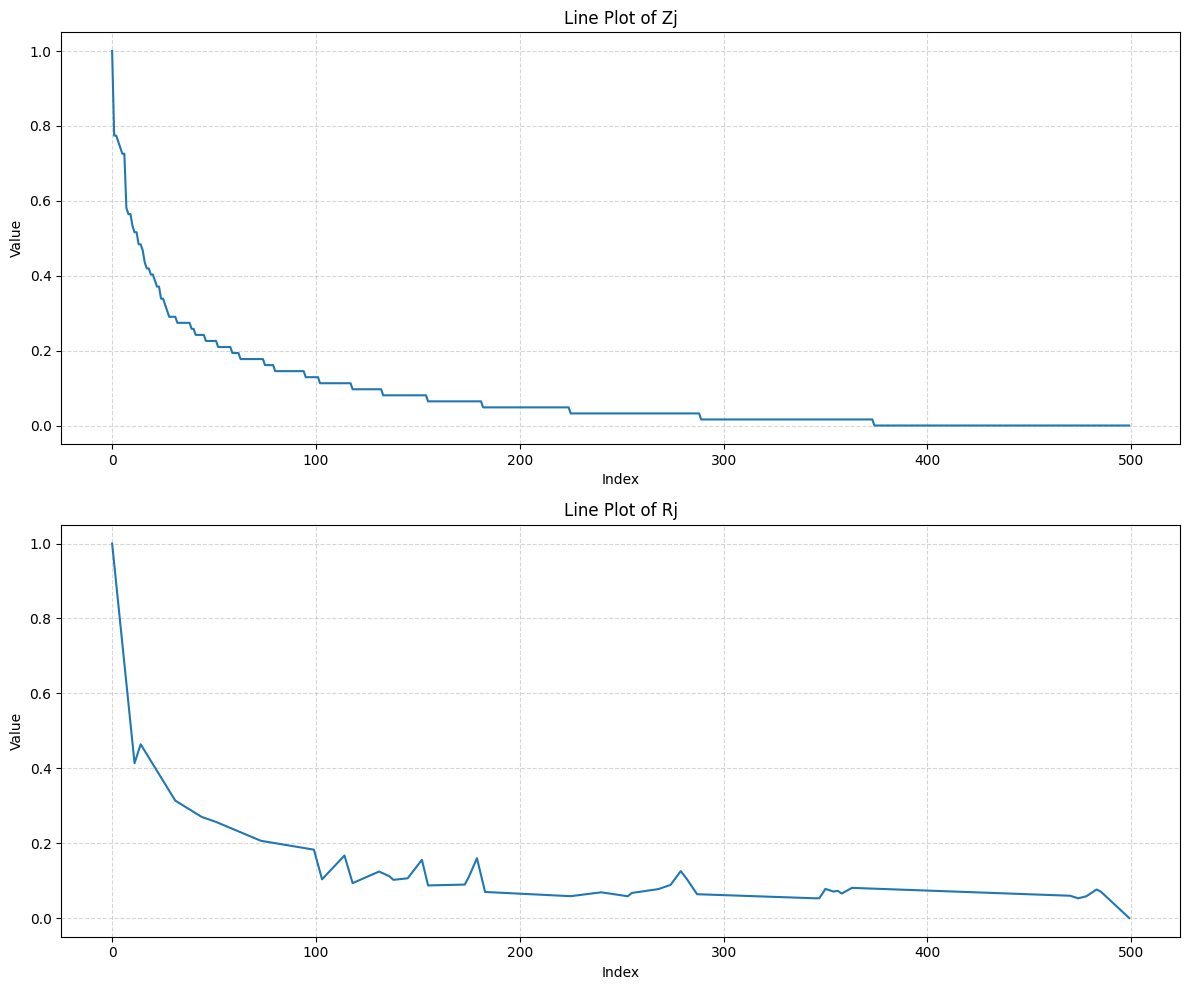

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Escalar objetivo
scaler = MinMaxScaler()
scaled_targets = scaler.fit_transform(Zj[:, 2].reshape(-1, 1)).flatten() # (500, 1)

# Crear una figura con dos subplots verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Primer subplot para Zj
x1 = np.arange(len(scaled_targets))
y1 = scaled_targets
ax1.plot(x1, y1)
ax1.set_xlabel('Index')
ax1.set_ylabel('Value')
ax1.set_title('Line Plot of Zj')
ax1.grid(True, linestyle='--', alpha=0.5)

# Segundo subplot para Rj
x2 = np.arange(len(Rj_fn))
y2 = Rj_fn
ax2.plot(x2, y2)
ax2.set_xlabel('Index')
ax2.set_ylabel('Value')
ax2.set_title('Line Plot of Rj')
ax2.grid(True, linestyle='--', alpha=0.5)

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

#### 3.4.3 Differential Evolution (DE)

In [ ]:
from scipy.optimize import differential_evolution

import numpy as np

def objective_function(params, dij, Ii, Zj, target_results):
    beta_r, gamma_r, alpha_p, gamma_p = params

    # Simulación con parámetros actuales
    simulation_results = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

    # Evaluación de la diferencia con los resultados esperados
    error = np.linalg.norm(simulation_results - target_results)

    print(f"PSO - Error: {error}\n, Params: {params}")

    return error

# # Límites de búsqueda para cada parámetro
# bounds = [(0.4, 0.6),  # beta_r: de 0.5 ± 0.1
#           (0.09, 0.13),  # gamma_r: de 0.11 ± 0.02
#           (0.9, 1.1),   # alpha_p: de 1.0 ± 0.1
#           (0.008, 0.012)]  # gamma_p: de 0.01 ± 0.002

# # Optimización con DE
# result_de = differential_evolution(
#     objective_function, bounds, args=(dij, Ii, Zj, scaled_targets),
#     strategy='best1bin', popsize=10, tol=1e-3, workers=1, disp=True
# )

# print("Parámetros óptimos encontrados:", result_de.x)
# print("Error final:", result_de.fun)

In [ ]:
# send_telegram_msg("Finalizó la Optimización con DE")
# send_telegram_msg(f"Parámetros DE óptimos encontrados: {result_de.x}")
# send_telegram_msg(f"Error final: {result_de.fun}")

#### 3.4.4 Particule Swarm Optimization (PSO)

In [ ]:
from pyswarm import pso

# Límites de búsqueda para cada parámetro
lb = [0.1, 0.01, 0.5, 0.001]  # Límites inferiores
ub = [1.0, 0.2, 2.0, 0.05]  # Límites superiores

# Optimización con PSO
best_params, best_error = pso(objective_function, lb, ub, args=(dij, Ii, Zj, scaled_targets))

print("Parámetros óptimos encontrados:", best_params)
print("Error final:", best_error)

Streaming output truncated to the last 5000 lines.
PSO - Error: 0.245569878536799
, Params: [0.1        0.19481631 0.97361214 0.03417604]
Starting loop ...

Total execution time:  9.556362867355347
PSO - Error: 0.24953973125110818
, Params: [0.10169061 0.19523639 0.96717781 0.03407631]
Starting loop ...

Total execution time:  9.445544719696045
PSO - Error: 0.24769468806251715
, Params: [0.1        0.19479176 0.97490499 0.03414639]
Starting loop ...

Total execution time:  9.527912855148315
PSO - Error: 0.2455763042548352
, Params: [0.10009081 0.19478404 0.97363968 0.03412244]
Starting loop ...

Total execution time:  9.446257591247559
PSO - Error: 0.2974242247049485
, Params: [0.1        0.19476888 0.97339085 0.03418733]
Starting loop ...

Total execution time:  9.549083232879639
PSO - Error: 0.36440610510016364
, Params: [0.1        0.19381705 0.96374012 0.03416104]
Starting loop ...

Total execution time:  9.458218574523926
PSO - Error: 0.24727382809967222
, Params: [0.1        0.19

##### 3.4.4.1 Results PSO

In [ ]:
"""Stopping search: Swarm best objective change less than 1e-08
Parámetros óptimos encontrados: [0.1        0.19482765 0.97356374 0.03415131]
Error final: 0.24425217952019052"""

#### 3.4.5 Gradient Descent L-BFGS-B (Limited-memory Broyden-Fletcher-Goldfarb-Shanno Bound-constrained)

In [ ]:
# from scipy.optimize import minimize

# # Límites de búsqueda para cada parámetro
# bounds = [(0.1, 1.0), (0.01, 0.2), (0.5, 2.0), (0.001, 0.05)]

# # Valores iniciales
# initial_params = [0.5, 0.1, 1.0, 0.02]

# # Optimización con descenso de gradiente
# result_gd = minimize(objective_function, initial_params, args=(dij, Ii, Zj, scaled_targets), bounds=bounds, method='L-BFGS-B')

# print("Parámetros óptimos encontrados:", result_gd.x)
# print("Error final:", result_gd.fun)